# Dummy Test for the OptiClean Optimization Model

This notebook checks that the mathematical optimization model works before we build the real Stage 1 and Stage 2 notebooks.

The real notebooks will replace the dummy demand matrix with predicted demand values from the machine learning models.

## 1. Imports

We import the optimization function from the project root. The small `sys.path` line is only needed because this notebook is inside the `notebooks/` folder.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from opticlean_optimization import solve_location_model

## 2. Create Dummy Candidate Sites

The optimization model needs one row per candidate store site. The required columns are:

- `cap_small`
- `cost_small`
- `cap_large`
- `cost_large`

The `lat` and `lon` columns are not used by the optimizer, but they are useful for visualization.

In [2]:
candidate_sites = pd.DataFrame(
    {
        "lat": [0.0, 4.0, 7.0],
        "lon": [0.0, 2.5, 0.5],
        "cap_small": [180, 160, 140],
        "cost_small": [110, 100, 90],
        "cap_large": [300, 260, 240],
        "cost_large": [180, 170, 160],
    },
    index=["S1", "S2", "S3"],
)

candidate_sites

,lat,lon,cap_small,cost_small,cap_large,cost_large
S1,0.0,0.0,180,110,300,180
S2,4.0,2.5,160,100,260,170
S3,7.0,0.5,140,90,240,160


## 3. Create Dummy Potential Clients

The optimizer itself does not need client coordinates. We include them here only to make the result easy to plot.

In [3]:
potential_clients = pd.DataFrame(
    {
        "lat": [0.4, 1.0, 3.8, 5.0, 6.6, 0.2],
        "lon": [0.5, 1.2, 2.7, 1.8, 0.2, -0.2],
    },
    index=["C1", "C2", "C3", "C4", "C5", "C6"],
)

potential_clients

,lat,lon
C1,0.4,0.5
C2,1.0,1.2
C3,3.8,2.7
C4,5.0,1.8
C5,6.6,0.2
C6,0.2,-0.2


## 4. Create a Dummy Demand Matrix

This matrix is the same type of object that Stage 1 and Stage 2 will eventually produce.

Each row is a potential client. Each column is a candidate site. Entry `(i, j)` is the weekly demand captured if client `i` is assigned to site `j`.

In [4]:
demand_matrix = pd.DataFrame(
    {
        "S1": [80, 70, 20, 0, 35, 65],
        "S2": [40, 65, 85, 75, 15, 20],
        "S3": [0, 10, 60, 90, 80, 5],
    },
    index=potential_clients.index,
)

demand_matrix

,S1,S2,S3
C1,80,40,0
C2,70,65,10
C3,20,85,60
C4,0,75,90
C5,35,15,80
C6,65,20,5


## 5. Solve the Optimization Model

The model decides:

- which candidate sites to open,
- whether each opened site is small or large,
- which clients to assign to which opened site.

In [5]:
result = solve_location_model(
    demand_matrix=demand_matrix,
    candidate_sites=candidate_sites,
    budget=280,
    verbose=False,
)

print("Objective value:", result["objective_value"])
print("Budget used:", result["budget_used"])
print("Unassigned clients:", result["unassigned_clients"])

Restricted license - for non-production use only - expires 2027-11-29
Objective value: 410.0
Budget used: 280.0
Unassigned clients: []


## 6. Selected Sites

This table shows the opened stores, selected format, capacity, cost, and capacity utilization.

In [6]:
selected_sites = result["selected_sites"]
selected_sites

,site_id,format,capacity,cost,used_capacity,capacity_utilization
0,S1,large,300.0,180.0,250.0,0.833333
1,S2,small,160.0,100.0,160.0,1.000000


## 7. Client Assignments

This table shows which clients are assigned and how much predicted demand is captured from each assignment.

In [7]:
assignments = result["assignments"]
assignments

,client_id,site_id,captured_demand
0,C1,S1,80.0
1,C2,S1,70.0
2,C3,S2,85.0
3,C4,S2,75.0
4,C5,S1,35.0
5,C6,S1,65.0


## 8. Visualize the Solution

Clients are colored by assigned store. Candidate sites are shown as X markers. Opened stores are larger and labeled with their selected format.

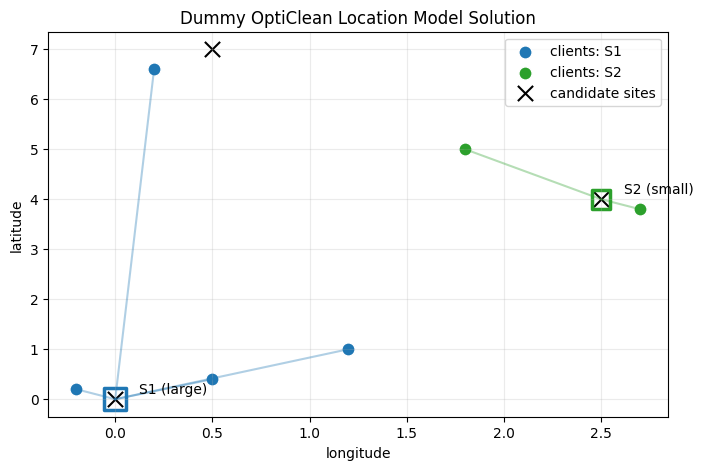

In [8]:
plot_clients = potential_clients.copy()
plot_clients["assigned_site"] = "unassigned"

for _, row in assignments.iterrows():
    plot_clients.loc[row["client_id"], "assigned_site"] = row["site_id"]

colors = {
    "S1": "tab:blue",
    "S2": "tab:green",
    "S3": "tab:orange",
    "unassigned": "lightgray",
}

fig, ax = plt.subplots(figsize=(8, 5))

for group, data in plot_clients.groupby("assigned_site"):
    ax.scatter(
        data["lon"],
        data["lat"],
        s=90,
        label=f"clients: {group}",
        color=colors.get(group, "black"),
        edgecolor="white",
    )

ax.scatter(
    candidate_sites["lon"],
    candidate_sites["lat"],
    marker="x",
    s=120,
    color="black",
    label="candidate sites",
)

for _, row in selected_sites.iterrows():
    site = row["site_id"]
    ax.scatter(
        candidate_sites.loc[site, "lon"],
        candidate_sites.loc[site, "lat"],
        marker="s",
        s=260 if row["format"] == "large" else 180,
        facecolor="none",
        edgecolor=colors.get(site, "black"),
        linewidth=2.5,
    )
    ax.text(
        candidate_sites.loc[site, "lon"] + 0.12,
        candidate_sites.loc[site, "lat"] + 0.12,
        f"{site} ({row['format']})",
        fontsize=10,
    )

for _, row in assignments.iterrows():
    client = row["client_id"]
    site = row["site_id"]
    ax.plot(
        [potential_clients.loc[client, "lon"], candidate_sites.loc[site, "lon"]],
        [potential_clients.loc[client, "lat"], candidate_sites.loc[site, "lat"]],
        color=colors.get(site, "black"),
        alpha=0.35,
    )

ax.set_title("Dummy OptiClean Location Model Solution")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.show()

## 9. What This Confirms

If this notebook runs, then the optimization part is working. The next task is to replace the dummy `demand_matrix` with predictions from Stage 1 or Stage 2.